# Taller 04: Descubriendo Patrones Musicales con Spotify

## 1. Descripción del Caso
Imagina que trabajas como Data Scientist en una plataforma de streaming musical emergente. El equipo de producto quiere mejorar el sistema de recomendación, pero no tienen etiquetas claras para ciertos tipos de canciones.

Te entregan este conjunto de datos sobre 999 canciones y sus caracteristicas https://www.kaggle.com/datasets/glowstudygram/spotify-songs-and-artists-dataset

El objetivo de la actividad es usar algoritmos de agrupamiento (Clustering) para agrupar las canciones más populares del 2023 basándote únicamente en sus características de audio, ignorando el género o el artista. Luego, deberás interpretar qué representa cada grupo.

## 2. Objetivos de Aprendizaje
* Limpieza de datos.
* Estandarización de variables.
* Reducción de dimensionalidad (PCA).
* Clustering (K-Means o DBScan).
* Interpretación de resultados.

### Bloque 1: Configuración y Carga de Datos
Importa las librerías necesarias y carga el dataset.

In [1]:
# 1. Importación de Librerías
!pip install scikit-learn

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_csv("spotifydataset.csv")
data.info()


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudne

### Bloque 2: Limpieza y Preparación
Se debe trabajar solamente con las columnas que describen como es la canción en terminos auditivos:

- track_popularity
- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

No se deben usar columnas como el artista o genero para evitar sesgos en la agrupación

In [23]:
columnas_a_eliminar = ['Unnamed: 0', 'artist_name', 'genres', 'artist_url', 'track_name', 'track_name' , 'album_name', 'explicit', 'release_date', 'followers','artist_popularity']
data_limpia = data.drop(columns=columnas_a_eliminar, errors='ignore')

data_limpia


,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,228639,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,173639,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,92400,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,191013,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,214994,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,369573,69,0.751,0.708,0,-5.653,1,0.0545,0.0482,0.000018,0.1070,0.509,108.970
996,324373,64,0.792,0.701,6,-7.198,0,0.2830,0.1050,0.000000,0.7610,0.251,103.890
997,304226,60,0.746,0.978,9,-5.324,1,0.0978,0.0555,0.000041,0.0260,0.653,153.809
998,222653,59,0.749,0.856,2,-5.833,1,0.2350,0.1070,0.000000,0.7450,0.402,103.773


In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Se hace un escalamiento de los datos

StandardScaler = StandardScaler()
data_scaled = StandardScaler.fit_transform(data_limpia)

### Bloque 3: Reducción de Dimensionalidad (PCA)
Reduce los datos a 2 componentes principales para poder visualizarlos en un gráfico 2D.

In [26]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

In [27]:
pca.explained_variance_ratio_
pca.explained_variance_ratio_.sum()
pca.components_

array([[-0.06505279,  0.17315553,  0.26249014,  0.47243839,  0.03462863,
         0.49677216, -0.05805751,  0.10122846, -0.41935348, -0.38216808,
         0.13422905,  0.25596006,  0.08150966],
       [-0.40054534,  0.18826864,  0.48409452, -0.28671193,  0.12444314,
        -0.15206448, -0.15923023,  0.17951054,  0.28155181, -0.17175144,
        -0.23545057,  0.39023685, -0.27365557]])

Text(0, 0.5, 'Componente principal 2')

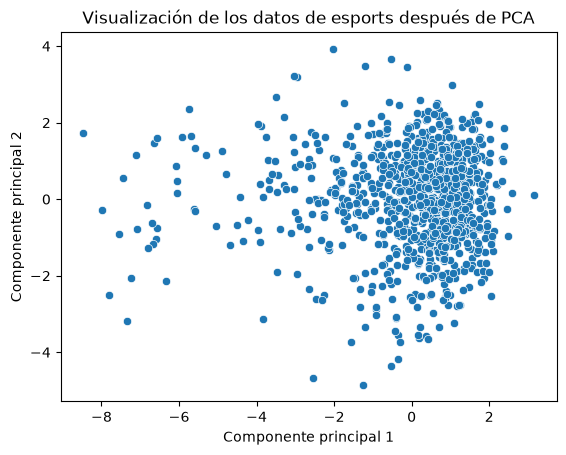

In [28]:
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1])
plt.title("Visualización de los datos de esports después de PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

### Bloque 4: Modelado (Usa K-Means o DB Scan para generar los clusters)

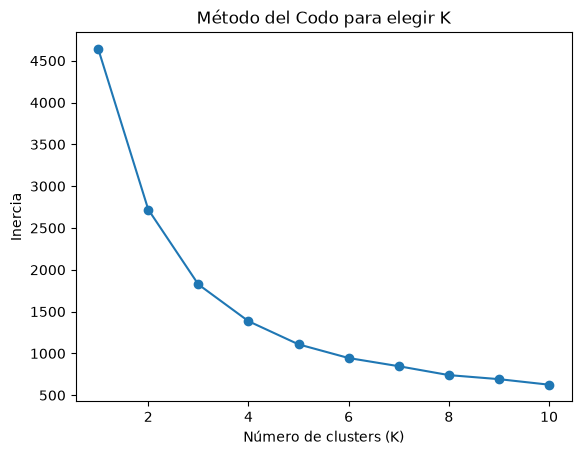

In [29]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(data_pca)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo para elegir K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

Text(0, 0.5, 'Componente principal 2')

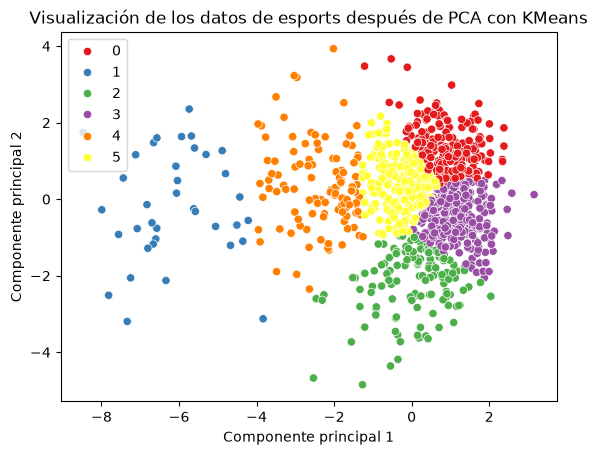

In [30]:
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(data_pca)

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=kmeans.labels_, palette='Set1')
plt.title("Visualización de los datos de esports después de PCA con KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

### Bloque 5: Visualización y Análisis
Genera visualizaciones que permitan interpretar qué significa cada grupo.

In [31]:
Clusters = pd.DataFrame(kmeans.labels_,columns=['Cluster'])
Clusters

,Cluster
0,5
1,0
2,4
3,3
4,0
...,...
995,3
996,3
997,3
998,3


In [44]:
data_clusters = data.merge(Clusters,left_index=True,right_index=True)

Text(0.5, 1.0, 'Track')

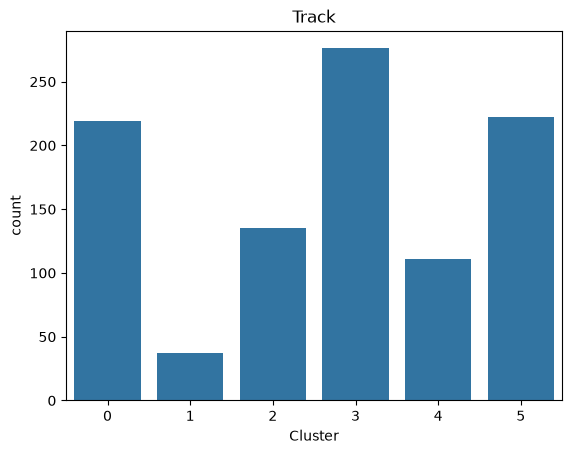

In [45]:
import seaborn as sns
sns.countplot(data=data_clusters,x='Cluster')  
plt.title('Track')

Text(0.5, 1.0, 'energy')

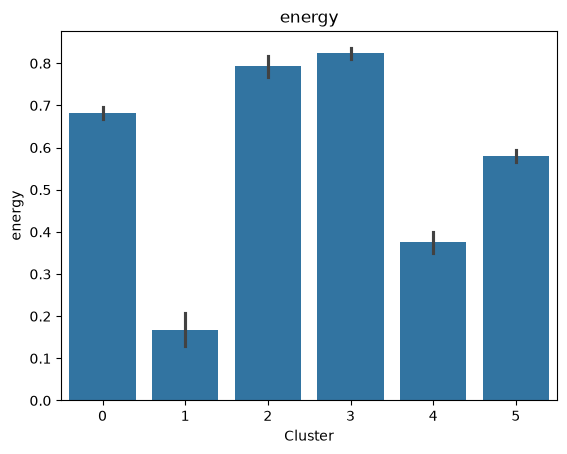

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='energy', estimator='mean')  
plt.title('energy')

Text(0.5, 1.0, 'liveness')

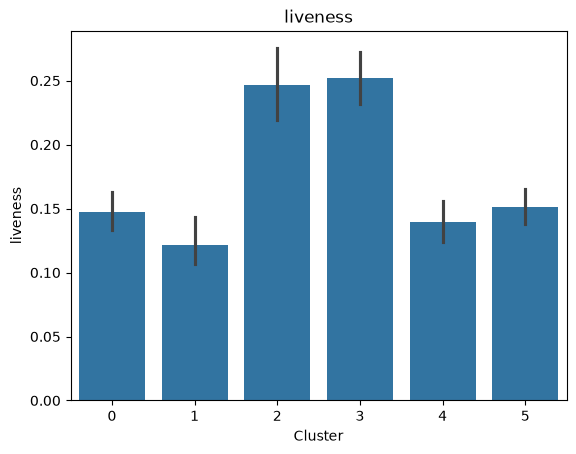

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='liveness', estimator='mean') 
plt.title('liveness')

Text(0.5, 1.0, 'loudness')

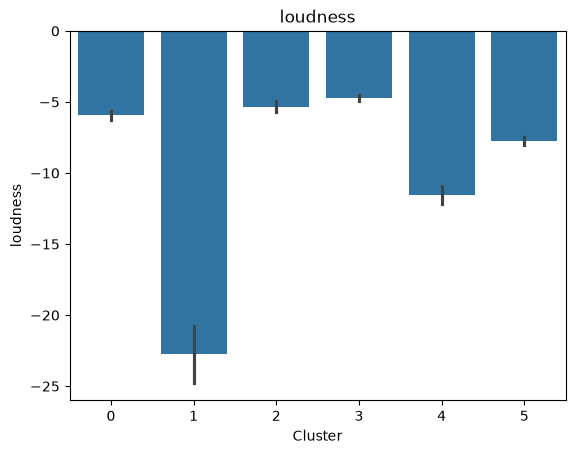

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='loudness', estimator='mean')  
plt.title('loudness')


Text(0.5, 1.0, 'acousticness')

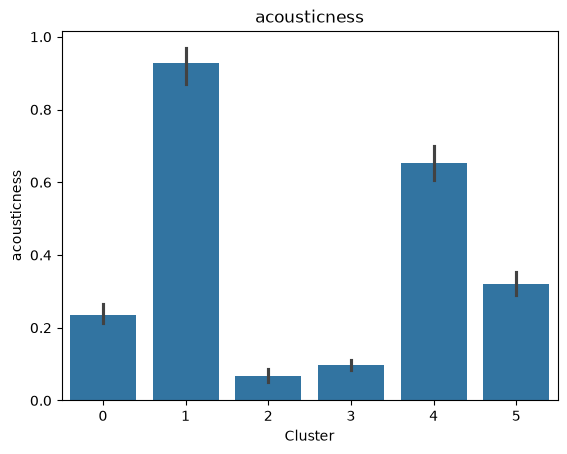

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='acousticness', estimator='mean')  
plt.title('acousticness')

Text(0.5, 1.0, 'speechiness')

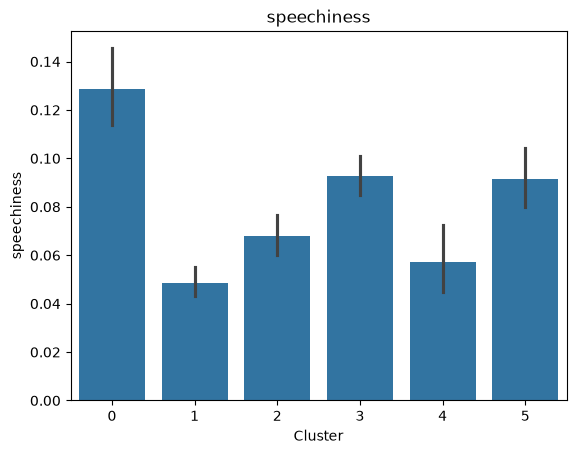

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='speechiness', estimator='mean')  
plt.title('speechiness')

Text(0.5, 1.0, 'tempo')

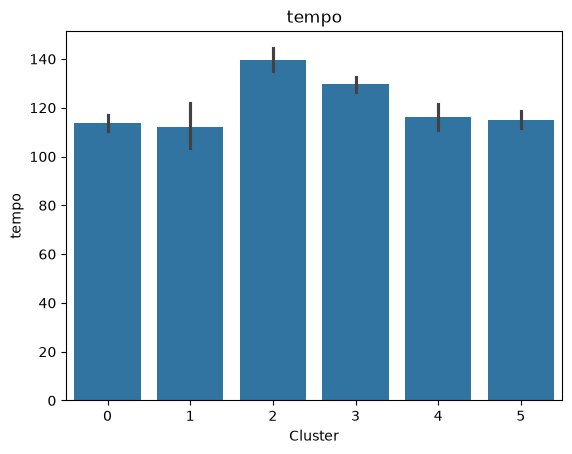

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='tempo', estimator='mean')  
plt.title('tempo')

Text(0.5, 1.0, 'danceability')

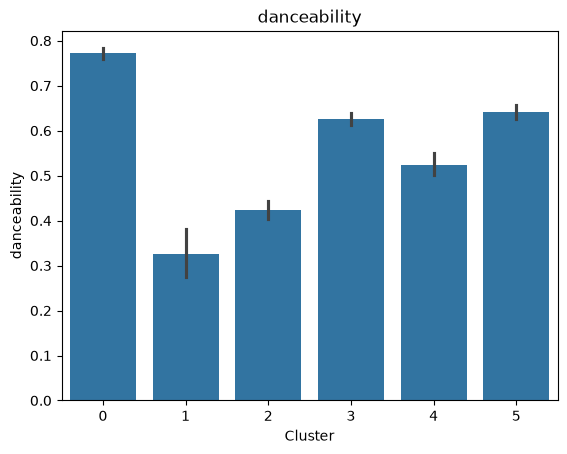

In [ ]:
import seaborn as sns
sns.barplot(data= data_clusters, x='Cluster', y='danceability', estimator='mean')  
plt.title('danceability')

<Axes: ylabel='Cluster'>

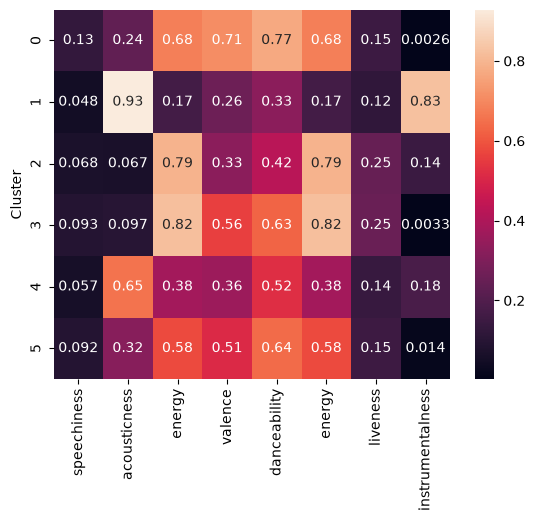

In [60]:
sns.heatmap(data_clusters[['Cluster','speechiness','acousticness','energy','valence','danceability','energy', 'liveness','instrumentalness']].groupby('Cluster').mean(), annot=True)

In [58]:
data_clusters [data_clusters['Cluster']==0]

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,Cluster
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998,0
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998,0
20,20,A$AP Rocky,"east coast hip hop, hip hop, rap",14740526,83,https://open.spotify.com/artist/13ubrt8QOOCPlj...,Sundress,Sundress,2018-11-20,158205,...,6,-6.364,1,0.0595,0.1810,0.000004,0.1430,0.743,125.005,0
22,22,A$AP Rocky,"east coast hip hop, hip hop, rap",14740526,81,https://open.spotify.com/artist/13ubrt8QOOCPlj...,Praise The Lord (Da Shine) (feat. Skepta),TESTING,2018-05-25,205040,...,5,-8.151,0,0.1060,0.0609,0.081600,0.1000,0.294,80.015,0
27,27,A$AP Rocky,"east coast hip hop, hip hop, rap",14740526,76,https://open.spotify.com/artist/13ubrt8QOOCPlj...,"F**kin' Problems (feat. Drake, 2 Chainz & Kend...",LONG.LIVE.A$AP (Deluxe Version),2013,233786,...,1,-6.870,1,0.2750,0.0239,0.000000,0.1100,0.662,95.967,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,990,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,84,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Hey Ya!,Speakerboxxx/The Love Below,2003,235213,...,4,-2.261,0,0.0664,0.1030,0.000532,0.1740,0.965,79.526,0
991,991,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,83,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,Ms. Jackson,Stankonia,2000-10-31,270506,...,4,-5.946,0,0.2690,0.1430,0.000000,0.0771,0.613,94.948,0
992,992,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,73,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,"So Fresh, So Clean",Stankonia,2000-10-31,240026,...,5,-7.905,0,0.3320,0.0281,0.000000,0.0990,0.915,166.028,0
993,993,Outkast,"atl hip hop, dirty south rap, hip hop, old sch...",2769972,71,https://open.spotify.com/artist/1G9G7WwrXka3Z1...,The Way You Move (feat. Sleepy Brown),Speakerboxxx/The Love Below,2003,234000,...,5,-4.932,0,0.0464,0.1260,0.000113,0.0638,0.635,125.999,0


### Conclusiones

Plantear 3 conclusiones propias basadas en los resultados obtenidos

1. Las Personas que tengan mas gusto por la musica instrumental, clasica,con mucha variabilidad interna (loudness muy negativo), perfecta para ambientar espacios o estudiar la lista del cluster numero 1 seria la ideal.

2. Si al igual que el anterior eres una persona con gusto por la musica acustica pero que contenga algo de letras, ademas de una energia suave con una dinamica mas natural, tu lista predilecta sera la # 4 

3. Si tu preferencia es la musica mas bailable, con una buena energia, instrumentos mas electricos, con bastante letra, con ritmo estándar modernas y un rango dinámico controlado. la lista perfecta sera la # 0